# Volcano plot

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [38]:
df = pd.read_csv("deseq2_results.csv")

In [39]:
# Remove rows with NaN padj
df = df.dropna(subset=['padj'])

In [40]:
# Handle padj = 0 by replacing with a very small number
df['padj_plot'] = df['padj'].replace(0, 1e-300)

# Calculate -log10(padj)
df['-log10(padj)'] = -np.log10(df['padj_plot'])

# Define significance
df['significant'] = (df['padj'] < 0.05) & (abs(df['log2FoldChange']) > 2)

In [41]:
# Get top 5 up and down regulated genes based on LOWEST padj
sig_genes = df[df['significant']].copy()
upregulated = sig_genes[sig_genes['log2FoldChange'] > 2]
downregulated = sig_genes[sig_genes['log2FoldChange'] < -2]

top5_up = upregulated.nsmallest(5, 'padj')
top5_down = downregulated.nsmallest(5, 'padj')
top_genes = pd.concat([top5_up, top5_down])

In [42]:
print(f"Top genes to highlight: {len(top_genes)}")
print(top_genes[['gene_id', 'log2FoldChange', 'padj', '-log10(padj)']])

Top genes to highlight: 10
                  gene_id  log2FoldChange           padj  -log10(padj)
20084   ENSG00000276168.1       11.451045   0.000000e+00    300.000000
12955  ENSG00000147604.15        5.944595  3.515126e-188    187.454059
1885   ENSG00000177954.15        7.469887  6.728482e-186    185.172083
13819   ENSG00000277027.2        5.990569  2.555477e-176    175.592528
18451  ENSG00000229117.10        5.668731  3.327996e-141    140.477817
7554   ENSG00000145386.12       -7.196059   0.000000e+00    300.000000
24288  ENSG00000131747.16       -5.815709   0.000000e+00    300.000000
30535   ENSG00000211459.2      -10.715685   0.000000e+00    300.000000
30537   ENSG00000210082.2      -12.464342   0.000000e+00    300.000000
28236  ENSG00000101057.17       -8.600640  4.886826e-291    290.310973


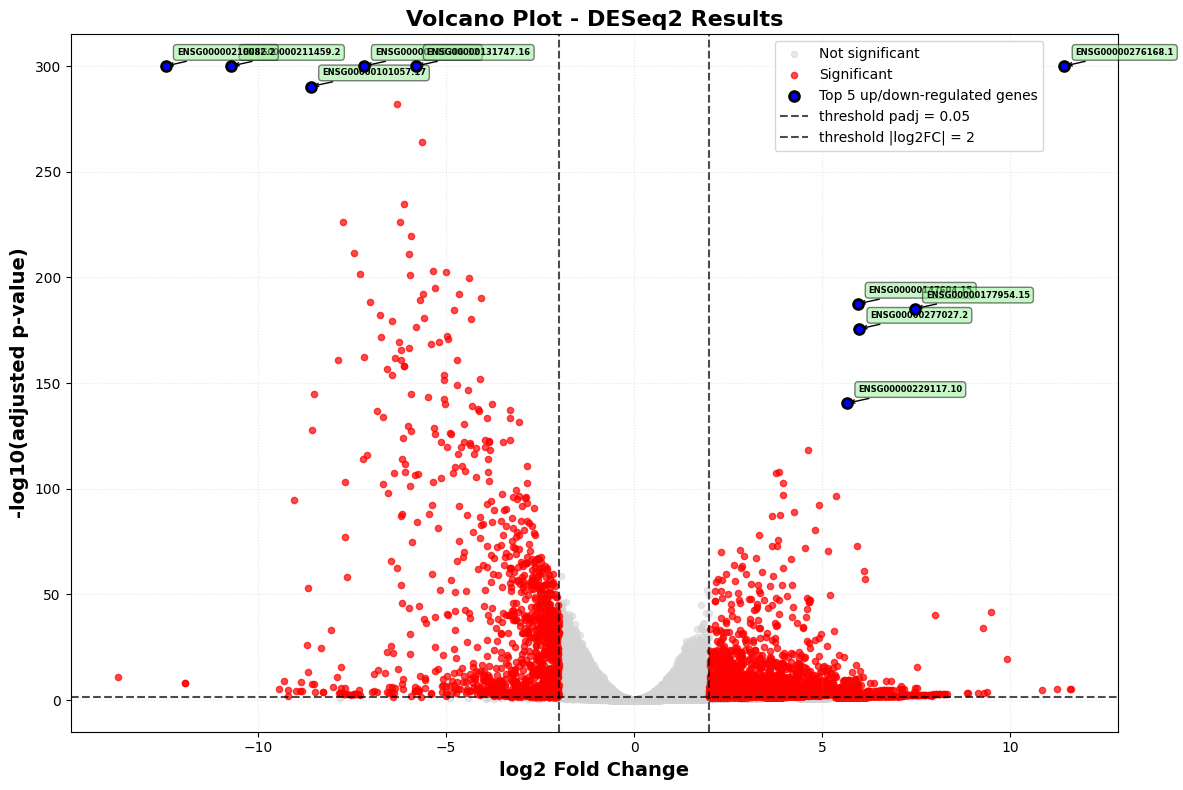

In [56]:
# Create volcano plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot non-significant genes
not_sig = df[~df['significant']]
ax.scatter(not_sig['log2FoldChange'], not_sig['-log10(padj)'], 
           c='lightgray', alpha=0.5, s=20, label='Not significant')

# Plot significant genes
sig = df[df['significant'] & ~df.index.isin(top_genes.index)]
ax.scatter(sig['log2FoldChange'], sig['-log10(padj)'], 
           c='red', alpha=0.7, s=20, label='Significant')

# Highlight top genes - plot them LAST so they're on top
ax.scatter(top_genes['log2FoldChange'], top_genes['-log10(padj)'], 
           c='blue', s=50, edgecolors='black', linewidths=2, 
           label=f'Top 5 up/down-regulated genes', zorder=10)

# Add gene labels for top genes
for idx, row in top_genes.iterrows():
    ax.annotate(row['gene_id'], 
                xy=(row['log2FoldChange'], row['-log10(padj)']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=6, ha='left', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', 
                         edgecolor='black', alpha=0.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))

# Add threshold lines
ax.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=1.5, 
           alpha=0.7, label='threshold padj = 0.05')
ax.axvline(x=2, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(x=-2, color='black', linestyle='--', linewidth=1.5, alpha=0.7, 
           label='threshold |log2FC| = 2')

# Labels and legend
ax.set_xlabel('log2 Fold Change', fontsize=14, fontweight='bold')
ax.set_ylabel('-log10(adjusted p-value)', fontsize=14, fontweight='bold')
ax.set_title('Volcano Plot - DESeq2 Results', fontsize=16, fontweight='bold')
ax.legend(bbox_to_anchor=(0.8,1), loc='upper center', fontsize=10)
ax.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('volcano_plot.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [44]:
# Print summary
print(f"\nTotal genes: {len(df)}")
print(f"Significant genes: {df['significant'].sum()}")
print(f"Significant upregulated: {len(upregulated)}")
print(f"Significant downregulated: {len(downregulated)}")
print(f"\nTop 5 upregulated (lowest padj):")
print(top5_up[['gene_id', 'log2FoldChange', 'padj']])
print(f"\nTop 5 downregulated (lowest padj):")
print(top5_down[['gene_id', 'log2FoldChange', 'padj']])


Total genes: 22270
Significant genes: 5004
Significant upregulated: 3822
Significant downregulated: 1182

Top 5 upregulated (lowest padj):
                  gene_id  log2FoldChange           padj
20084   ENSG00000276168.1       11.451045   0.000000e+00
12955  ENSG00000147604.15        5.944595  3.515126e-188
1885   ENSG00000177954.15        7.469887  6.728482e-186
13819   ENSG00000277027.2        5.990569  2.555477e-176
18451  ENSG00000229117.10        5.668731  3.327996e-141

Top 5 downregulated (lowest padj):
                  gene_id  log2FoldChange           padj
7554   ENSG00000145386.12       -7.196059   0.000000e+00
24288  ENSG00000131747.16       -5.815709   0.000000e+00
30535   ENSG00000211459.2      -10.715685   0.000000e+00
30537   ENSG00000210082.2      -12.464342   0.000000e+00
28236  ENSG00000101057.17       -8.600640  4.886826e-291
